# Learning Curve Analysis
Per-epoch train vs val loss & accuracy captured during `03_main_training.py` / `04_cross_dataset_training.py` runs.

Histories are stored in `classification_performances.joblib` under the key `train_history_{model_name}_`
(one per model per `res_entry`; each is a **list of dicts**, one dict per fold).

In [7]:
import sys, joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Point this at the experiment whose results you want to analyse ──────────
EXP_FOLDER = Path("/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260731_E00_C00_F4500KHz_U_DDM_01_04")
# EXP_FOLDER = Path("/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260804_E00_C00_F4500KHz_U_DDM_02_01")

RESULTS_FILE = EXP_FOLDER / "classification_performances.joblib"
results = joblib.load(RESULTS_FILE)
print(f"Loaded {RESULTS_FILE}")
print(f"Top-level keys: {list(results.keys())[:5]}")

Loaded /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260731_E00_C00_F4500KHz_U_DDM_01_04/classification_performances.joblib
Top-level keys: ['Ori Curves', 'Ori Curves Avg', 'Ori Curves Wavelet Sym8', 'Ori Curves Wavelet Bior35', 'Ori Curves Sg P4']


## 1 — Explorer: what history is available?

In [13]:
for exp_title, modes in results.items():
    for mode_key, filters in modes.items():
        for filter_name, res in filters.items():
            hist_keys = sorted(k for k in res if k.startswith('train_history'))
            if hist_keys:
                n_folds = len(res[hist_keys[0]])
                models  = [k.replace('train_history_','').rstrip('_') for k in hist_keys]
                print(f"{exp_title} | {mode_key} | {str(filter_name)[:40]}")
                print(f"  models ({n_folds} folds): {models}")
                print()

Ori Curves Wavelet Bior35 | Native | None
  models (1 folds): ['cnn_gru_dual_attn_recon_supcon2', 'cnn_gru_dual_attn_recon_supcon3', 'cnn_gru_dual_attn_recon_supcon', 'cnn_gru_dual_supcon2', 'cnn_gru_dual_supcon3', 'cnn_gru_dual_supcon']

Ori Curves Sg P4 | Native | None
  models (1 folds): ['cnn_gru_dual_attn_recon_supcon2', 'cnn_gru_dual_attn_recon_supcon3', 'cnn_gru_dual_attn_recon_supcon', 'cnn_gru_dual_supcon2', 'cnn_gru_dual_supcon3', 'cnn_gru_dual_supcon']



## 2 — Pick a result entry to inspect

In [19]:
# ── Choose one entry ─────────────────────────────────────────────
TARGET_EXP    = list(results.keys())[3]          # first experiment
TARGET_MODE   = list(results[TARGET_EXP].keys())[0]
TARGET_FILTER = list(results[TARGET_EXP][TARGET_MODE].keys())[0]

res = results[TARGET_EXP][TARGET_MODE][TARGET_FILTER]
hist_keys = sorted(k for k in res if k.startswith('train_history'))
print(f"Entry : {TARGET_EXP} | {TARGET_MODE} | {TARGET_FILTER}")
print(f"Models: {[k.replace('train_history_','').rstrip('_') for k in hist_keys]}")
if hist_keys:
    sample = res[hist_keys[0]][0]
    print(f"Metric keys in fold 0: {list(sample.keys())}")

Entry : Ori Curves Wavelet Bior35 | Native | None
Models: ['cnn_gru_dual_attn_recon_supcon2', 'cnn_gru_dual_attn_recon_supcon3', 'cnn_gru_dual_attn_recon_supcon', 'cnn_gru_dual_supcon2', 'cnn_gru_dual_supcon3', 'cnn_gru_dual_supcon']
Metric keys in fold 0: ['cls_ce', 'loss', 'supcon', 'val_cls_ce', 'val_loss', 'val_supcon', 'learning_rate']


## 3 — Helper functions

In [24]:
def _get(histories, key):
    # List of np arrays (one per fold) for a given metric key
    return [np.array(h[key]) for h in histories if key in h]

def _pad_mean(arrays):
    # Nan-padded mean across arrays of different lengths
    if not arrays:
        return np.array([])
    maxlen = max(len(a) for a in arrays)
    padded = np.full((len(arrays), maxlen), np.nan)
    for i, a in enumerate(arrays):
        padded[i, :len(a)] = a
    return np.nanmean(padded, axis=0)

def _best_epoch(histories, val_key='val_loss'):
    # Epoch index of minimum val_loss per fold (where available)
    out = []
    for h in histories:
        if val_key in h:
            out.append(int(np.argmin(h[val_key])))
        else:
            out.append(len(h.get('loss', [])) - 1)
    return out

def _detect_metric_keys(history):
    # Return (loss_key, val_loss_key, acc_key, val_acc_key) for this history dict
    keys = set(history.keys())
    # loss
    lk  = 'loss'
    vlk = 'val_loss' if 'val_loss' in keys else None
    # accuracy — standard models use 'accuracy'; MTL models use 'cls_out_accuracy'
    if 'accuracy' in keys:
        ak, vak = 'accuracy', ('val_accuracy' if 'val_accuracy' in keys else None)
    elif 'cls_out_accuracy' in keys:
        ak, vak = 'cls_out_accuracy', ('val_cls_out_accuracy' if 'val_cls_out_accuracy' in keys else None)
    else:
        ak, vak = None, None
    return lk, vlk, ak, vak

## 4 — Per-model learning curves (loss + accuracy)

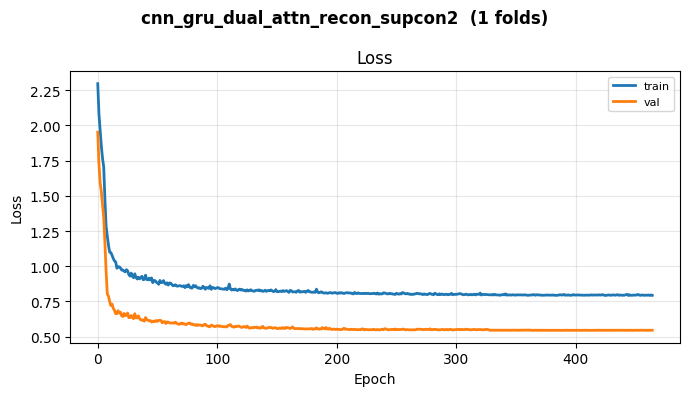

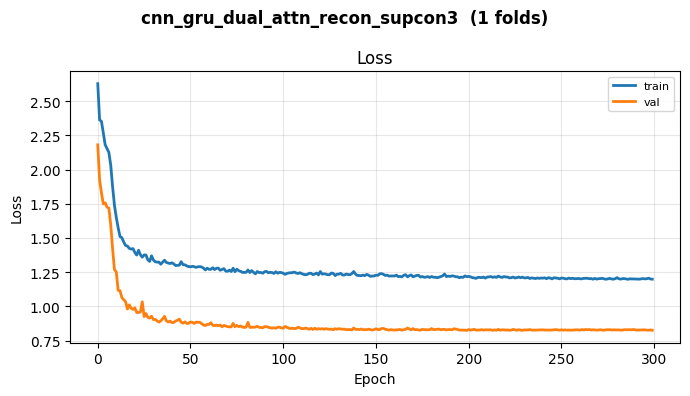

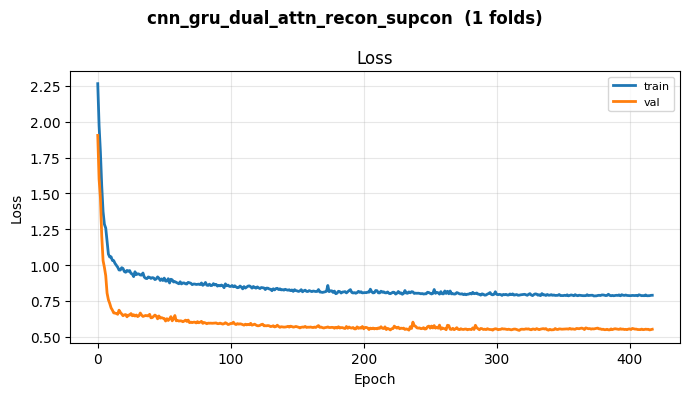

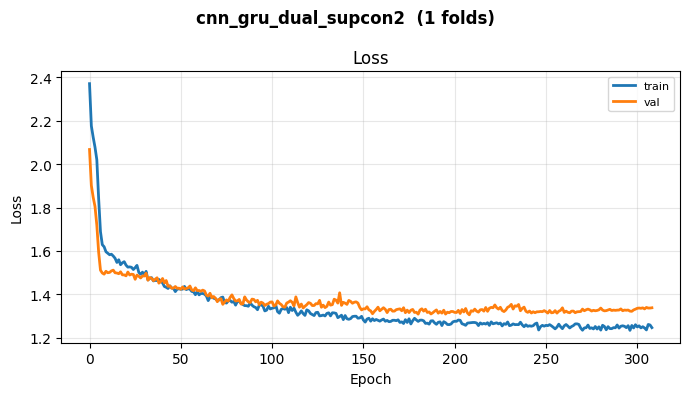

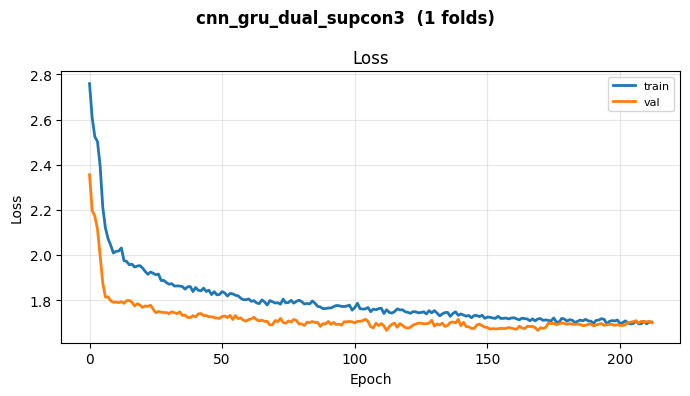

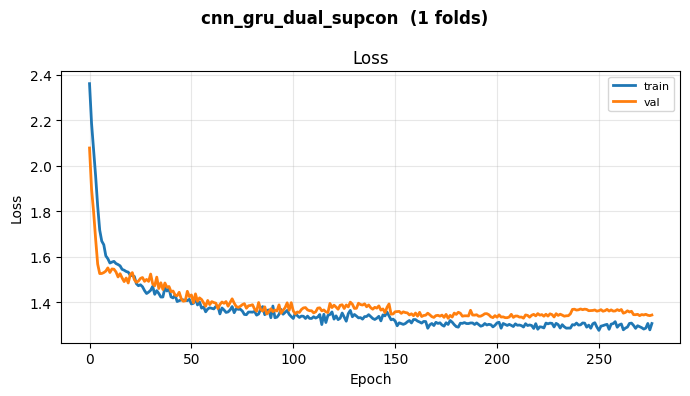

In [25]:
BLUE   = 'tab:blue'
ORANGE = 'tab:orange'
ALPHA  = 0.25

for hist_key in hist_keys:
    model_name = hist_key.replace('train_history_', '').rstrip('_')
    histories  = res[hist_key]
    if not histories:
        continue

    lk, vlk, ak, vak = _detect_metric_keys(histories[0])
    has_val  = vlk is not None
    has_acc  = ak  is not None

    ncols = 1 + int(has_acc)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f"{model_name}  ({len(histories)} folds)", fontsize=12, fontweight='bold')

    # ── Loss panel ──────────────────────────────────────────────────────────
    ax = axes[0]
    train_l = _get(histories, lk)
    val_l   = _get(histories, vlk) if has_val else []

    for arr in train_l:
        ax.plot(arr, color=BLUE,   alpha=ALPHA, lw=0.8)
    for arr in val_l:
        ax.plot(arr, color=ORANGE, alpha=ALPHA, lw=0.8)
    if train_l:
        ax.plot(_pad_mean(train_l), color=BLUE,   lw=2, label='train')
    if val_l:
        ax.plot(_pad_mean(val_l),   color=ORANGE, lw=2, label='val')

    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('Loss'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── Accuracy panel ──────────────────────────────────────────────────────
    if has_acc:
        ax = axes[1]
        train_a = _get(histories, ak)
        val_a   = _get(histories, vak) if vak else []

        for arr in train_a:
            ax.plot(arr, color=BLUE,   alpha=ALPHA, lw=0.8)
        for arr in val_a:
            ax.plot(arr, color=ORANGE, alpha=ALPHA, lw=0.8)
        if train_a:
            ax.plot(_pad_mean(train_a), color=BLUE,   lw=2, label='train')
        if val_a:
            ax.plot(_pad_mean(val_a),   color=ORANGE, lw=2, label='val')

        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
        ax.set_title('Accuracy'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5 — Convergence: how many epochs did each model train?

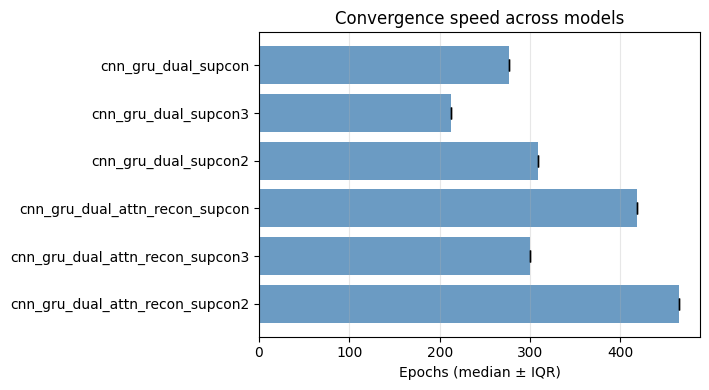

In [26]:
conv_data = {}
for hist_key in hist_keys:
    model_name = hist_key.replace('train_history_', '').rstrip('_')
    histories  = res[hist_key]
    if not histories:
        continue
    # Use length of val_loss if available (early stopping cuts it), else loss
    epochs_run = [len(h.get('val_loss', h['loss'])) for h in histories]
    conv_data[model_name] = epochs_run

if conv_data:
    fig, ax = plt.subplots(figsize=(max(6, len(conv_data) * 1.2), 4))
    names  = list(conv_data.keys())
    meds   = [np.median(v) for v in conv_data.values()]
    q1s    = [np.percentile(v, 25) for v in conv_data.values()]
    q3s    = [np.percentile(v, 75) for v in conv_data.values()]
    xerr   = np.array([[m - q1 for m, q1 in zip(meds, q1s)],
                        [q3 - m for m, q3 in zip(meds, q3s)]])
    x = np.arange(len(names))
    ax.barh(x, meds, xerr=xerr, color='steelblue', alpha=0.8, capsize=4)
    ax.set_yticks(x); ax.set_yticklabels(names)
    ax.set_xlabel('Epochs (median ± IQR)')
    ax.set_title('Convergence speed across models')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

## 6 — Best val_loss across folds (model comparison)

/tmp/ipykernel_1105124/611978731.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names, patch_artist=True, notch=False)


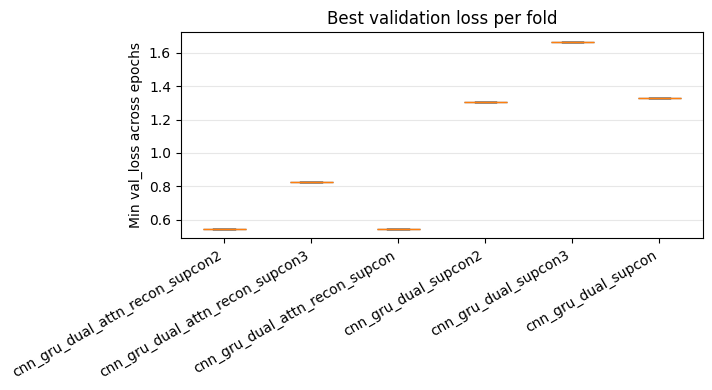

In [27]:
best_val = {}
for hist_key in hist_keys:
    model_name = hist_key.replace('train_history_', '').rstrip('_')
    histories  = res[hist_key]
    bests = []
    for h in histories:
        if 'val_loss' in h:
            bests.append(float(np.min(h['val_loss'])))
    if bests:
        best_val[model_name] = bests

if best_val:
    fig, ax = plt.subplots(figsize=(max(6, len(best_val) * 1.2), 4))
    names = list(best_val.keys())
    data  = list(best_val.values())
    bp = ax.boxplot(data, labels=names, patch_artist=True, notch=False)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue'); patch.set_alpha(0.6)
    ax.set_ylabel('Min val_loss across epochs')
    ax.set_title('Best validation loss per fold')
    ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()

## 7 — Cross-experiment comparison (same model, different experiments)

Change `COMPARE_MODEL` to whichever model you want to compare across experiments.

No history found for model 'cnn_gru_dual'. Check the model name above.


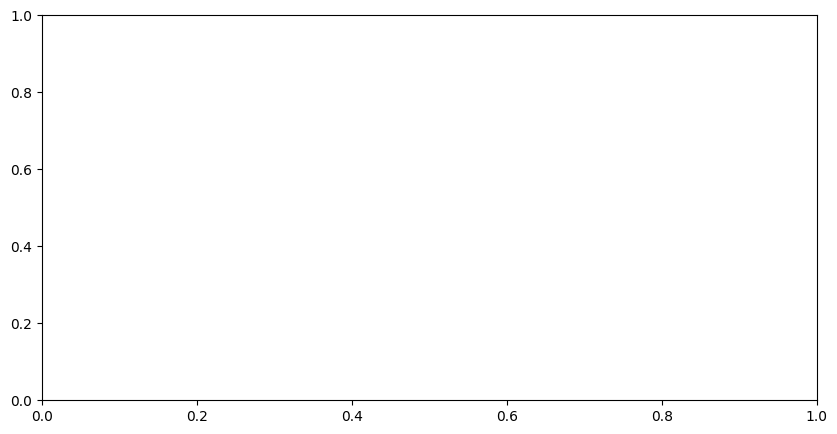

In [28]:
COMPARE_MODEL = 'cnn_gru_dual'   # change to the model you want to compare
COMPARE_METRIC = 'val_loss'

fig, ax = plt.subplots(figsize=(10, 5))
found_any = False
for exp_title, modes in results.items():
    for mode_key, filters in modes.items():
        for filter_name, res_e in filters.items():
            key = f'train_history_{COMPARE_MODEL}_'
            if key not in res_e:
                continue
            hists = res_e[key]
            vals  = _get(hists, COMPARE_METRIC)
            if not vals:
                continue
            mean_curve = _pad_mean(vals)
            label = f"{exp_title[:30]} | {filter_name[:20]}"
            ax.plot(mean_curve, lw=1.5, label=label)
            found_any = True

if found_any:
    ax.set_xlabel('Epoch'); ax.set_ylabel(COMPARE_METRIC)
    ax.set_title(f'{COMPARE_MODEL} — {COMPARE_METRIC} across experiments (mean over folds)')
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f"No history found for model '{COMPARE_MODEL}'. Check the model name above.")